# End-to-End Evaluation

In [1]:
import os, sys, glob
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter, MaxNLocator
from Cofi import style

%matplotlib inline
style.apply()
FONT_SIZE = style.FONT_SIZE
DATA, FIG = "data", "figures"
os.makedirs(FIG, exist_ok=True)
pd.set_option("display.width", 160)
qnum = lambda q: int("".join(c for c in q if c.isdigit()) or 0)

R = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{DATA}/e2e-runs*.csv"))], ignore_index=True)
R["C"] = R["C_usd"] * style.COST_SCALE
EST = pd.read_csv(f"{DATA}/sweep-plans.csv")
# a validate plan equal to another plan of its query was run once: copy the runs of that plan under its name
ALIAS = pd.read_csv(f"{DATA}/validate-aliases.csv")
_v = R[R.experiment == "validate"]
_has = lambda q, p: ((_v["query"] == q) & (_v.plan == p)).any()
R = pd.concat([R] + [_v[(_v["query"] == a.query) & (_v.plan == a.same_as)].assign(plan=a.plan)
                     for a in ALIAS.itertuples() if not _has(a.query, a.plan)], ignore_index=True)
MED = R.groupby(["experiment", "query", "plan"]).agg(runs=("T_s", "size"), T=("T_s", "median"), T_lo=("T_s", "min"),
        T_hi=("T_s", "max"), C=("C", "median"), C_lo=("C", "min"), C_hi=("C", "max")).reset_index()
med = lambda e, p: MED[(MED.experiment == e) & (MED.plan == p)]
R.groupby(["experiment", "plan"]).size().rename("runs").to_frame().T

experiment baseline    s3opt                                  sweep                          validate                                                        \
plan          no_bf all_mp20 default scan_mp20 scan_opt best_global default knee min_C min_T  default front_01 front_02 front_03 front_04 front_05 front_06   
runs            285       57      57        57       57           9       9    9     9     9       60       60       57       57       54       54       51   

experiment                   
plan       knee min_C min_T  
runs         60    54    60

## Final results: total time and cost over the queries

In [2]:
E2E_SET = next(e for e in ("validate", "grid", "sweep") if (R.experiment == e).any())
NOBF_SET = E2E_SET if len(med(E2E_SET, "no_bf")) else "baseline"   # non-BF runs of the same session, if any
REF, NOBF = "BLOOM-FaaS BF always on", "BLOOM-FaaS non-BF"         # REF: reference of the percentages (or NOBF)
SYSTEMS = [(NOBF_SET, "no_bf", NOBF, "#8a8983"),
           (E2E_SET, "default", REF, "#52514e"),
           (E2E_SET, "knee", "BLOOM-FaaS opti", "#2a78d6"),
           (E2E_SET, "min_T", "BLOOM-FaaS Min-time", "#eb6834"),
           (E2E_SET, "min_C", "BLOOM-FaaS Min-money", "#1baf7a")]
have = [set(med(e, p)["query"]) for e, p, _, _ in SYSTEMS]
QS_E2E = sorted(set.intersection(*have), key=qnum)
KEYS = ["T", "T_lo", "T_hi", "C", "C_lo", "C_hi"]
TOT = pd.DataFrame([{"system": lab, "color": col, **med(e, p).query("query in @QS_E2E")[KEYS].sum()}
                    for e, p, lab, col in SYSTEMS]).set_index("system")
REF_SUFFIX = "" if REF != NOBF else "-vs-nobf"     # figures with the non-BF reference are saved next to the others
for ref, name in [(REF, REF.replace("BLOOM-FaaS ", ""))] + ([(NOBF, "non-BF")] if REF != NOBF else []):
    for k in ("T", "C"):
        TOT[f"Δ{k} vs {name}"] = (TOT[k] / TOT.loc[ref, k] - 1).map("{:+.1%}".format)
print(f"experiment: {E2E_SET}, {len(QS_E2E)} queries: {', '.join(q.upper() for q in QS_E2E)}")
print("left out (a system not measured):", ", ".join(q.upper() for q in sorted(set.union(*have) - set(QS_E2E), key=qnum)) or "-")
TOT.drop(columns="color").round(2)

experiment: validate, 19 queries: Q2, Q3, Q4, Q5, Q7, Q8, Q9, Q10, Q11, Q12, Q13, Q14, Q15, Q16, Q17, Q18, Q19, Q20, Q21
left out (a system not measured): -


,T,T_lo,T_hi,C,C_lo,C_hi,ΔT vs BF always on,ΔC vs BF always on,ΔT vs non-BF,ΔC vs non-BF
system,,,,,,,,,,
BLOOM-FaaS non-BF,550.06,524.85,577.65,160.51,155.04,167.22,+79.2%,+198.1%,+0.0%,+0.0%
BLOOM-FaaS BF always on,306.91,302.55,315.05,53.85,52.67,55.14,+0.0%,+0.0%,-44.2%,-66.5%
BLOOM-FaaS opti,300.32,288.22,314.94,47.96,47.34,48.49,-2.1%,-10.9%,-45.4%,-70.1%
BLOOM-FaaS Min-time,311.68,303.72,334.06,62.03,61.35,62.95,+1.6%,+15.2%,-43.3%,-61.4%
BLOOM-FaaS Min-money,368.95,363.84,383.40,42.60,41.16,43.08,+20.2%,-20.9%,-32.9%,-73.5%


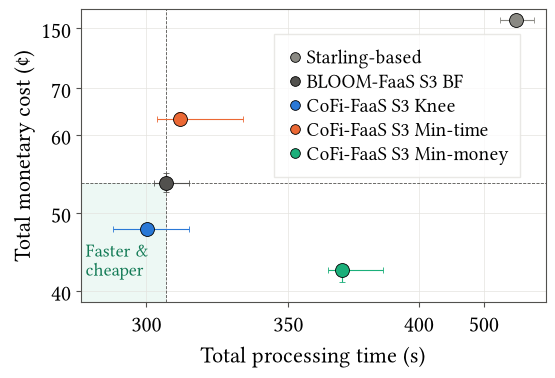

In [3]:
X_SCALE = Y_SCALE = None          # dict(knots=[...], shares=[...]) or None (auto)
X_TICKS = Y_TICKS = None          # list of ticks or None (auto)
SHARE_BF = 0.72                   # share of the axis for the BF systems, the rest up to non-BF
DISPLAY_NAME = {"BLOOM-FaaS non-BF": "Starling-based",
                "BLOOM-FaaS BF always on": "BLOOM-FaaS S3 BF",
                "BLOOM-FaaS opti": "CoFi-FaaS S3 Knee",
                "BLOOM-FaaS Min-time": "CoFi-FaaS S3 Min-time",
                "BLOOM-FaaS Min-money": "CoFi-FaaS S3 Min-money"}
TRADEOFF_TEXT = dict(label=FONT_SIZE + 3, tick=FONT_SIZE + 3, legend=FONT_SIZE + 1, region=FONT_SIZE)


def piecewise(knots, shares):
    """Axis scale: [knots[i], knots[i+1]] takes shares[i] of the axis, linear beyond the ends."""
    knots, pos = np.asarray(knots, float), np.concatenate([[0], np.cumsum(shares)])

    def interp(v, xp, fp):
        v = np.asarray(v, float)
        below = fp[0] + (v - xp[0]) * (fp[1] - fp[0]) / (xp[1] - xp[0])
        above = fp[-1] + (v - xp[-1]) * (fp[-1] - fp[-2]) / (xp[-1] - xp[-2])
        return np.where(v < xp[0], below, np.where(v > xp[-1], above, np.interp(v, xp, fp)))

    return (lambda v: interp(v, knots, pos)), (lambda p: interp(p, pos, knots))


def auto_scale(k):
    """BF systems (with their error bars) on the first SHARE_BF of the axis, non-BF on the rest."""
    bf, nobf = TOT.drop(index=NOBF), TOT.loc[NOBF]
    lo, hi = bf[f"{k}_lo"].min(), bf[f"{k}_hi"].max()
    pad = (hi - lo) * 0.12
    top = nobf[f"{k}_hi"] + (nobf[f"{k}_hi"] - lo) * 0.06
    return dict(knots=[lo - pad, hi + pad, top], shares=[SHARE_BF, 1 - SHARE_BF])


def nice_ticks(scale, n=(4, 2), min_gap=0.08):
    """Round ticks in each segment of a piecewise scale, dropping those closer than min_gap of the axis."""
    knots = scale["knots"]
    fwd = piecewise(knots, scale["shares"])[0]
    out = {t for (a, b), k in zip(zip(knots[:-1], knots[1:]), n)
           for t in MaxNLocator(nbins=k, steps=[1, 2, 2.5, 5, 10]).tick_values(a, b) if knots[0] <= t <= knots[-1]}
    keep = []
    for t in sorted(out):
        if not keep or fwd(t) - fwd(keep[-1]) >= min_gap * sum(scale["shares"]):
            keep.append(t)
    return keep


def set_piecewise(axis, scale, ticks=None, n=(4, 2)):
    """Piecewise scale, limits and plain-number ticks on one axis (ax.xaxis / ax.yaxis)."""
    ax, which = axis.axes, axis.axis_name
    getattr(ax, f"set_{which}scale")("function", functions=piecewise(scale["knots"], scale["shares"]))
    getattr(ax, f"set_{which}lim")(scale["knots"][0], scale["knots"][-1])
    axis.set_major_locator(FixedLocator(ticks or nice_ticks(scale, n)))
    axis.set_minor_locator(NullLocator())
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))


def tradeoff_chart(name):
    ts, ref = TRADEOFF_TEXT, TOT.loc[REF]
    xs, ys = X_SCALE or auto_scale("T"), Y_SCALE or auto_scale("C")
    fig, ax = plt.subplots(figsize=(6, 3.8))
    set_piecewise(ax.xaxis, xs, X_TICKS); set_piecewise(ax.yaxis, ys, Y_TICKS)
    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
    x0, y0 = xs["knots"][0], ys["knots"][0]
    ax.fill_between([x0, ref["T"]], y0, ref["C"], color="#1baf7a", alpha=0.08, lw=0, zorder=0)
    ax.text(x0, y0, " Faster &\n cheaper\n", ha="left", va="bottom", fontsize=ts["region"], color="#127a55", linespacing=1.0)
    ax.axvline(ref["T"], color=style.INK2, lw=0.6, ls="--", zorder=1); ax.axhline(ref["C"], color=style.INK2, lw=0.6, ls="--", zorder=1)
    for _, r in TOT.iterrows():
        ax.errorbar(r["T"], r["C"], xerr=[[r["T"] - r["T_lo"]], [r["T_hi"] - r["T"]]], yerr=[[r["C"] - r["C_lo"]], [r["C_hi"] - r["C"]]],
                    fmt="o", ms=10, color=r["color"], mec="black", mew=0.6, ecolor=r["color"], elinewidth=0.8, capsize=2, zorder=3)
    handles = [Line2D([], [], ls="", marker="o", ms=7, mfc=c, mec="black", mew=0.6) for c in TOT["color"]]
    names = [DISPLAY_NAME.get(lab, lab.replace("BLOOM-FaaS ", "")) for lab in TOT.index]
    ax.legend(handles, names, loc="lower center", bbox_to_anchor=(0.68, 0.395), frameon=True, fancybox=False,
              fontsize=ts["legend"], edgecolor=style.GRID, handlelength=1, handletextpad=0.1, labelspacing=0.1, borderpad=0.6)
    ax.set_xlabel("Total processing time (s)", fontsize=ts["label"])
    ax.set_ylabel(f"Total monetary cost ({style.COST_UNIT})", fontsize=ts["label"])
    ax.tick_params(labelsize=ts["tick"])
    style.save(fig, FIG, name)
    plt.show()


tradeoff_chart("e2e-total-tradeoff" + REF_SUFFIX)

## Per-stage sizes from the sweep (Q3, Q9, Q18): measured vs. estimated

In [4]:
PLAN_ORDER = ["no_bf", "default", "knee", "min_T", "min_C"]
PLAN_LABEL = {"no_bf": "Starling-based", "default": "BLOOM-FaaS S3 BF", "knee": "CoFi-FaaS S3 Knee",
              "min_T": "CoFi-FaaS S3 Min-time", "min_C": "CoFi-FaaS S3 Min-money"}
PLAN_COLOR = {"no_bf": "#8a8983", "default": "#52514e", "knee": "#2a78d6", "min_T": "#eb6834", "min_C": "#1baf7a"}
S = MED[MED.experiment == "sweep"]
qs = sorted(S["query"].unique(), key=qnum)
# Starling-based = BLOOM-FaaS without Bloom filters: no_bf runs of the sweep when it has them, else the accuracy campaign's
if not (S.plan == "no_bf").any():
    S = pd.concat([S, med("baseline", "no_bf").query("query in @qs")], ignore_index=True)
SI, EI = S.set_index(["query", "plan"]), EST.set_index(["query", "plan"])
rows = []
for q in qs:
    d = SI.loc[(q, "default")]
    for p in PLAN_ORDER:
        r = SI.loc[(q, p)]
        t_est = EI["T_est_s"].get((q, p), np.nan)          # no estimate for no_bf
        rows.append({"query": q.upper(), "plan": PLAN_LABEL[p], "T meas (s)": r["T"], "T est (s)": t_est,
                     "err T": "-" if np.isnan(t_est) else f"{t_est / r['T'] - 1:+.0%}", "speedup": f"{d['T'] / r['T']:.2f}x",
                     f"C meas ({style.COST_UNIT})": r["C"], "saving": f"{1 - r['C'] / d['C']:+.0%}"})
pd.DataFrame(rows).set_index(["query", "plan"]).round(2)

T meas (s)  T est (s) err T speedup  C meas (¢) saving
query plan                                                                          
Q3    Starling-based               18.81        NaN     -   0.85x        4.72  -166%
      BLOOM-FaaS S3 BF             15.96      14.88   -7%   1.00x        1.77    +0%
      CoFi-FaaS S3 Knee            12.69      11.45  -10%   1.26x        1.60   +10%
      CoFi-FaaS S3 Min-time        11.67      10.25  -12%   1.37x        2.29   -29%
      CoFi-FaaS S3 Min-money       21.68      19.98   -8%   0.74x        1.06   +40%
Q9    Starling-based               77.15        NaN     -   0.34x       23.95  -308%
      BLOOM-FaaS S3 BF             26.60      28.34   +7%   1.00x        5.87    +0%
      CoFi-FaaS S3 Knee            26.99      26.71   -1%   0.99x        4.34   +26%
      CoFi-FaaS S3 Min-time        26.94      24.64   -9%   0.99x        5.11   +13%
      CoFi-FaaS S3 Min-money       45.39      43.81   -3%   0.59x        4.13   +30%
Q18   Starling-based               22.47        NaN     -   0.59x        5.19  -169%
      BLOOM-FaaS S3 BF             13.19      12.68   -4%   1.00x        1.93    +0%
      CoFi-FaaS S3 Knee            12.81      11.36  -11%   1.03x        1.41   +27%
      CoFi-FaaS S3 Min-time        11.66      10.77   -8%   1.13x        1.94    -0%
      CoFi-FaaS S3 Min-money       15.03      15.54   +3%   0.88x        1.39   +28%

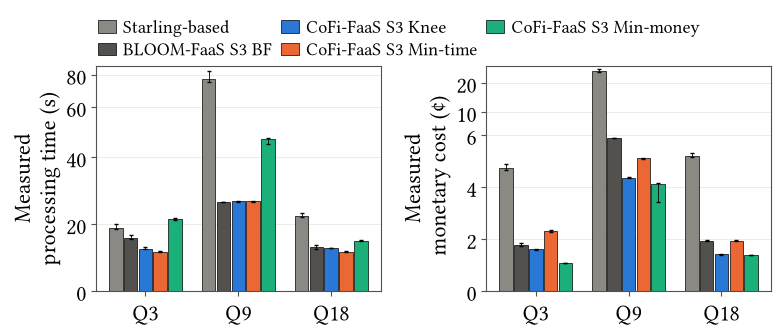

In [5]:
SWEEP_SCALE = {"T": None, "C": None}     # dict(knots=[...], shares=[...]) or None (auto)
SHARE_LOW = 0.75                         # share of the axis below the highest BF bar when no_bf is far above
SWEEP_TEXT = dict(label=FONT_SIZE + 3, tick=FONT_SIZE + 3, legend=FONT_SIZE)


def grouped(ax, data, qs, plans, key, ylabel, scale=None):
    sub = data.set_index(["query", "plan"])
    col = lambda c, p: sub.loc[[(q, p) for q in qs], c].to_numpy()
    if scale is None:
        bf = max(col(f"{key}_hi", p).max() for p in plans if p != "no_bf")
        top = max(col(f"{key}_hi", p).max() for p in plans)
        scale = (dict(knots=[0, bf * 1.1, top * 1.04], shares=[SHARE_LOW, 1 - SHARE_LOW]) if top > bf * 1.3
                 else dict(knots=[0, top * 1.08], shares=[1.0]))
    w = 0.8 / len(plans)
    for i, p in enumerate(plans):
        v, lo, hi = col(key, p), col(f"{key}_lo", p), col(f"{key}_hi", p)
        ax.bar(np.arange(len(qs)) + (i - (len(plans) - 1) / 2) * w, v, w * 0.92, color=PLAN_COLOR[p], edgecolor="black",
               lw=0.5, label=PLAN_LABEL[p], yerr=[v - lo, hi - v], error_kw={"elinewidth": 0.6, "capsize": 1.5, "ecolor": "black"}, zorder=2)
    set_piecewise(ax.yaxis, scale, n=(5, 2)[:len(scale["shares"])])
    ax.set_xticks(range(len(qs)), [q.upper() for q in qs])
    ax.set_ylabel(ylabel, fontsize=SWEEP_TEXT["label"])
    ax.tick_params(labelsize=SWEEP_TEXT["tick"])
    ax.grid(True, axis="y", color=style.GRID); ax.grid(False, axis="x"); ax.set_axisbelow(True)


fig, axs = plt.subplots(1, 2, figsize=(8, 3))
grouped(axs[0], S, qs, PLAN_ORDER, "T", "Measured\nprocessing time (s)", SWEEP_SCALE["T"])
grouped(axs[1], S, qs, PLAN_ORDER, "C", f"Measured\n monetary cost ({style.COST_UNIT})", SWEEP_SCALE["C"])
fig.legend(*axs[0].get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.51, 1.15),
           fontsize=SWEEP_TEXT["legend"], handlelength=1, handletextpad=0.4, columnspacing=0.5, labelspacing=0.1, borderpad=0.4)
fig.tight_layout()
style.save(fig, FIG, "e2e-sweep-plans")
plt.show()

## Limiting concurrent functions (19 queries): speedup and saving vs. the default plan

In [6]:
# totals over the 19 queries, and the no-BF baseline
O = MED[MED.experiment == "s3opt"].set_index(["query", "plan"])
qs = sorted(O.index.get_level_values(0).unique(), key=qnum)
D = O.xs("default", level="plan")
B = MED[MED.experiment == "baseline"].set_index("query").loc[qs]
rows = []
for p in ["default", "scan_mp20", "scan_opt", "all_mp20"]:
    sub = O.xs(p, level="plan")
    sp = D["T"] / sub["T"]
    rows.append({"plan": p, "total T (s)": sub["T"].sum(), f"total C ({style.COST_UNIT})": sub["C"].sum(),
                 "geomean speedup": np.exp(np.log(sp).mean()),
                 "median saving": f"{np.median(100 * (1 - sub['C'] / D['C'])):.0f}%",
                 "queries faster >5%": int((sp > 1.05).sum()), "queries slower >5%": int((sp < 0.95).sum())})
rows.append({"plan": "no_bf (baseline)", "total T (s)": B["T"].sum(), f"total C ({style.COST_UNIT})": B["C"].sum(),
             "geomean speedup": np.exp(np.log(D.loc[qs, "T"] / B["T"]).mean())})
pd.DataFrame(rows).set_index("plan").round(2)

## Validation (19 queries): optimized plans vs. the default plan, measured vs. estimated

Per query, median of the runs of `knee`, `min_T` and `min_C` against `default` (every Bloom filter on, 50 MB):
speedup = T_default / T_plan, saving = 1 − C_plan / C_default. The estimate error is T_est / T_meas − 1 (resp. C).

In [8]:
VEST = pd.read_csv(f"{DATA}/validate-plans.csv")
VEST["C_est"] = VEST["C_est_usd"] * style.COST_SCALE
V = MED[MED.experiment == "validate"].merge(VEST[["query", "plan", "T_est_s", "C_est"]], on=["query", "plan"], how="left")
V["err_T"] = V["T_est_s"] / V["T"] - 1
V["err_C"] = V["C_est"] / V["C"] - 1
VQS = sorted(V["query"].unique(), key=qnum)
VI = V.set_index(["query", "plan"])
rows = []
for q in VQS:
    d = VI.loc[(q, "default")]
    r = {"query": q.upper(), "T default (s)": d["T"], f"C default ({style.COST_UNIT})": d["C"]}
    for p in ["knee", "min_T", "min_C"]:
        if (q, p) in VI.index:
            x = VI.loc[(q, p)]
            r[f"{p} speedup"] = d["T"] / x["T"]
            r[f"{p} saving"] = f"{1 - x['C'] / d['C']:+.0%}"
    rows.append(r)
pd.DataFrame(rows).set_index("query").round(2)

,T default (s),C default (¢),knee speedup,knee saving,min_T speedup,min_T saving,min_C speedup,min_C saving
query,,,,,,,,
Q2,4.15,0.12,1.10,-4%,1.03,-46%,1.08,+18%
Q3,15.43,1.80,1.09,+31%,1.34,-5%,0.74,+47%
Q4,7.57,0.45,1.00,-29%,1.11,-130%,0.90,-10%
Q5,33.75,8.77,1.05,+4%,0.98,-8%,0.86,+11%
Q7,23.04,5.00,1.00,+17%,0.90,-38%,0.84,+24%
Q8,15.13,1.79,1.07,+6%,1.05,-10%,0.83,+7%
Q9,27.99,7.02,0.83,+6%,0.72,-33%,0.82,+22%
Q10,29.73,6.03,1.11,-1%,1.02,-17%,0.88,+20%
Q11,4.32,0.12,1.09,-19%,0.83,-82%,1.03,+23%


In [10]:
# estimate accuracy over all measured plans (incl. front_*, a plan aliased to another one counted once)
acc = V.dropna(subset=["T_est_s"]).merge(ALIAS[["query", "plan"]], how="left", indicator=True)
acc = acc[acc._merge == "left_only"].drop(columns="_merge")
summ = acc.groupby("plan").agg(queries=("query", "size"), T_meas=("T", "sum"), T_est=("T_est_s", "sum"),
                               C_meas=("C", "sum"), C_est=("C_est", "sum"),
                               MAPE_T=("err_T", lambda e: e.abs().mean()), MAPE_C=("err_C", lambda e: e.abs().mean()))
summ.loc["all"] = [len(acc), acc["T"].sum(), acc["T_est_s"].sum(), acc["C"].sum(), acc["C_est"].sum(),
                   acc["err_T"].abs().mean(), acc["err_C"].abs().mean()]
summ[["MAPE_T", "MAPE_C"]] = summ[["MAPE_T", "MAPE_C"]].map("{:.1%}".format)
summ.round(2)

,queries,T_meas,T_est,C_meas,C_est,MAPE_T,MAPE_C
plan,,,,,,,
default,19.0,306.91,283.14,53.85,51.63,17.3%,19.7%
front_02,18.0,285.32,214.76,49.88,48.84,20.6%,18.0%
front_03,17.0,295.79,232.47,47.15,43.98,17.7%,16.3%
front_04,18.0,312.94,263.75,46.21,41.24,16.1%,17.5%
front_05,18.0,324.97,289.24,44.98,39.96,15.8%,19.0%
knee,19.0,300.32,236.18,47.96,44.78,16.9%,17.8%
min_C,18.0,361.93,353.78,41.87,38.79,13.4%,17.3%
min_T,18.0,304.66,200.65,61.30,68.96,29.4%,23.3%
all,145.0,2492.85,2073.98,393.20,378.17,18.4%,18.6%


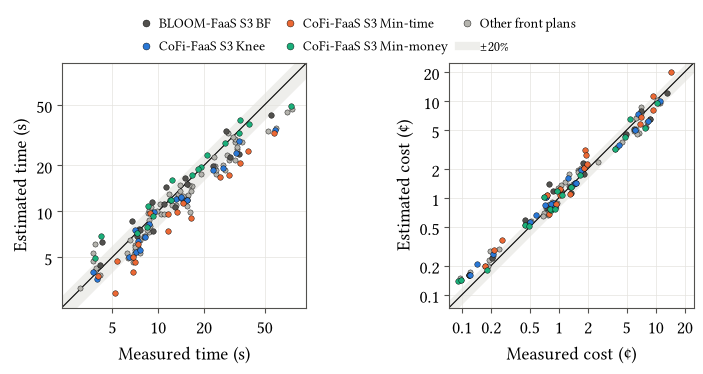

In [11]:
# estimated vs. measured on log-log axes (the points spread over two orders of magnitude); band = ±BAND
BAND = 0.20
ACC_ORDER = ["default", "knee", "min_T", "min_C"]          # legend order; other plans drawn grey as "Other front plans"
OTHER = "#b5b4ae"
NICE = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200]
fig, axs = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, (m, e, lab) in zip(axs, [("T", "T_est_s", "time (s)"), ("C", "C_est", f"cost ({style.COST_UNIT})")]):
    other = acc[~acc.plan.isin(ACC_ORDER)]
    ax.scatter(other[m], other[e], s=14, color=OTHER, edgecolor="black", lw=0.3, zorder=2)
    for p in ACC_ORDER:
        g = acc[acc.plan == p]
        ax.scatter(g[m], g[e], s=16, color=PLAN_COLOR[p], edgecolor="black", lw=0.3, zorder=3)
    vals = pd.concat([acc[m], acc[e]])
    lo, hi = vals.min() * 0.8, vals.max() * 1.25
    xs = np.geomspace(lo, hi, 50)
    ax.plot(xs, xs, color="black", lw=0.8, zorder=1)
    ax.fill_between(xs, xs * (1 - BAND), xs * (1 + BAND), color=style.GRID, alpha=0.6, lw=0, zorder=0)
    ax.set_xscale("log"); ax.set_yscale("log")
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(FixedLocator([t for t in NICE if lo <= t <= hi])); axis.set_minor_locator(NullLocator())
        axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.grid(True, color=style.GRID); ax.set_axisbelow(True)
    ax.set_xlabel(f"Measured {lab}"); ax.set_ylabel(f"Estimated {lab}")
mk = lambda col: Line2D([], [], ls="", marker="o", ms=5, mfc=col, mec="black", mew=0.3)
h = [mk(PLAN_COLOR[p]) for p in ACC_ORDER] + [mk(OTHER), Line2D([], [], color=style.GRID, lw=6, alpha=0.6)]
l = [PLAN_LABEL[p] for p in ACC_ORDER] + ["Other front plans", f"±{BAND:.0%}"]
fig.legend(h, l, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.12), fontsize=FONT_SIZE - 3,
           handlelength=1.2, handletextpad=0.3, columnspacing=0.8)
fig.tight_layout()
style.save(fig, FIG, "e2e-validate-accuracy")
plt.show()

## Estimated vs. measured Pareto front

In [12]:
PTS = pd.read_csv(f"{DATA}/validate-points.csv")          # = section 3 data/points.csv
PTS["C"] = PTS["C"] * style.COST_SCALE
GRAY, BLUE, ORANGE, GREEN, MEAS = "#c9c8c2", "#2a78d6", "#eb6834", "#1baf7a", "#000000"   # section 3 colours
PAD = 0.08
DASHED = (0, (2, 1.5))                                    # edge of the measured knee circle


def measured_front(q):
    """Measured plans of q (median T, C) that no other measured plan beats in both, sorted by T."""
    d = V[(V["query"] == q) & V["T_est_s"].notna()]
    d = d.assign(_o=d.plan.map({"default": 0, "knee": 1, "min_T": 2, "min_C": 3}).fillna(4)).sort_values("_o")
    d = d.drop_duplicates(subset=["T", "C"])              # an aliased plan (front_01 = min_T, ...) once, by its name
    T, C = d["T"].to_numpy(), d["C"].to_numpy()
    beaten = ((T[None, :] <= T[:, None]) & (C[None, :] <= C[:, None]) & ((T[None, :] < T[:, None]) | (C[None, :] < C[:, None]))).any(axis=1)
    return d[~beaten].sort_values("T")


def front_ends(F):
    """min-T, knee, min-C of a front sorted by T; knee as in plan_opt.py: closest to (T_min, C_min) after normalising."""
    knee = F.loc[((F["T"] / F["T"].min() - 1) ** 2 + (F["C"] / F["C"].min() - 1) ** 2).idxmin()]
    return F.iloc[0], knee, F.iloc[-1]


def front_panel(ax, q):
    # estimated: every evaluated plan, the Pareto front, knee / min-T / min-C
    R = PTS[PTS["query"] == q]
    F = R[R.pareto].sort_values("T")
    ax.scatter(R["T"], R["C"], s=5, color=GRAY, lw=0, rasterized=True)
    ax.plot(F["T"], F["C"], color=BLUE, lw=1.4, zorder=2)
    ax.scatter(F["T"], F["C"], s=14, color=BLUE, edgecolor="white", lw=0.6, zorder=3)
    est = lambda p: ([VI.loc[(q, p), "T_est_s"]], [VI.loc[(q, p), "C_est"]])
    ax.scatter(*est("knee"), s=95, facecolor="none", edgecolor="black", lw=1.2, zorder=4)
    ax.scatter(*est("min_T"), marker="^", s=30, color=ORANGE, edgecolor="white", lw=0.6, zorder=5)
    ax.scatter(*est("min_C"), marker="s", s=30, color=GREEN, edgecolor="white", lw=0.6, zorder=5)
    # measured: same shapes, hollow
    M = measured_front(q)
    ax.plot(M["T"], M["C"], color=MEAS, lw=1.3, ls="--", marker="o", ms=3.2, zorder=6)   # dots: a front of one plan stays visible
    mt, mk_, mc = front_ends(M)
    ax.scatter([mk_["T"]], [mk_["C"]], s=95, facecolor="none", edgecolor="black", lw=1.2, ls=DASHED, zorder=7)
    ax.scatter([mt["T"]], [mt["C"]], marker="^", s=42, facecolor="white", edgecolor=ORANGE, lw=1.3, zorder=8)
    ax.scatter([mc["T"]], [mc["C"]], marker="s", s=36, facecolor="white", edgecolor=GREEN, lw=1.3, zorder=8)
    ax.grid(True, color=style.GRID, lw=0.6); ax.set_axisbelow(True)
    for vals, setlim in ((pd.concat([F["T"], M["T"]]), ax.set_xlim), (pd.concat([F["C"], M["C"]]), ax.set_ylim)):
        lo, hi = vals.min(), vals.max()
        pad = (hi - lo) * PAD or lo * 0.05
        setlim(lo - pad, hi + pad)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 4, 5, 10], min_n_ticks=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10], min_n_ticks=3))


LEGEND_OPTS = dict(frameon=True, fancybox=False, edgecolor=style.GRID, frame_lw=0.8,
                   handlelength=1, handletextpad=0.5, columnspacing=0.5, labelspacing=0.1, borderpad=0.4)


def front_legend(fig, est, meas, opts=None):
    """Two legend boxes, estimated and measured. est / meas: dict(x, y, ncol, loc, fontsize), (x, y) in figure
    coordinates (0..1), `loc` = the corner of the box placed at (x, y). opts: overrides of LEGEND_OPTS (box style,
    spacing) for both boxes; est / meas may also carry any of those keys to override one box only."""
    mk = lambda m, ms, fc, ec="white", mew=0.6: Line2D([], [], ls="", marker=m, ms=ms, mfc=fc, mec=ec, mew=mew)
    boxes = [
        ("Estimated", est,
         [mk("o", 4, GRAY, GRAY, 0), Line2D([], [], color=BLUE, lw=1.4, marker="o", ms=6, mfc=BLUE, mec="white", mew=0.6),
          mk("o", 11, "none", "black", 1.2), mk("^", 8, ORANGE), mk("s", 7, GREEN)],
         ["Evaluated plans", "Pareto front", "Knee", "Min-time", "Min-money"]),
        ("Measured", meas,
         [Line2D([], [], color=MEAS, lw=1.3, ls="--", marker="o", ms=3.2),
          fig.axes[0].scatter([], [], s=95, facecolor="none", edgecolor="black", lw=1.2, ls=DASHED),   # dashed circle
          mk("^", 8, "white", ORANGE, 1.3), mk("s", 7, "white", GREEN, 1.3)],
         ["Pareto front", "Knee", "Min-time", "Min-money"]),
    ]
    for title, pos, h, l in boxes:
        pos = {"ncol": 3, "loc": "upper center", "fontsize": FONT_SIZE, **LEGEND_OPTS, **(opts or {}), **pos}
        x, y, fs, frame_lw = (pos.pop(k) for k in ("x", "y", "fontsize", "frame_lw"))
        leg = fig.legend(h, l, bbox_to_anchor=(x, y), fontsize=fs, title=title, title_fontsize=fs, **pos)
        leg.get_frame().set_linewidth(frame_lw)

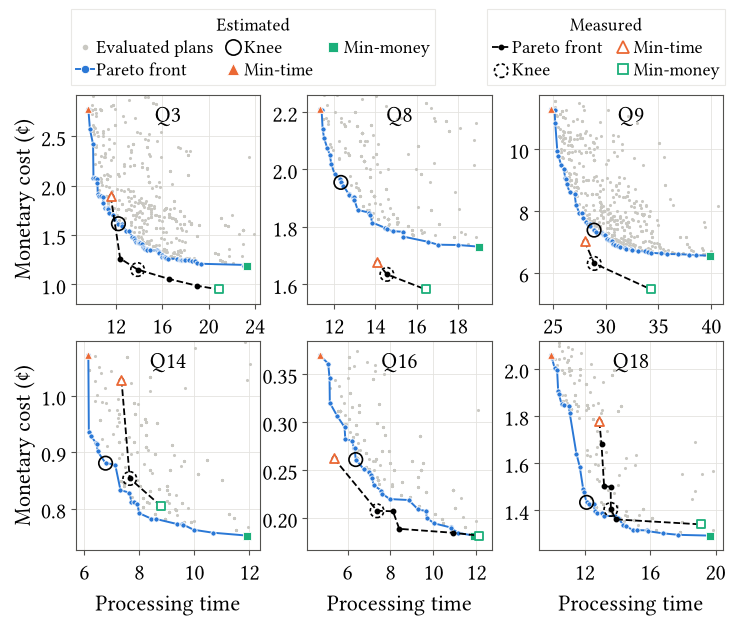

In [13]:
FRONT_QS = ["q3", "q8", "q9", "q14", "q16", "q18"]
NCOL = 3
LEGEND_EST = dict(x=0.34, y=0.99, ncol=3, loc="upper center", fontsize=FONT_SIZE)
LEGEND_MEAS = dict(x=0.83, y=0.99, ncol=2, loc="upper center", fontsize=FONT_SIZE)
LEGEND_TOP = 0.99                                         # inches kept above the panels for the legends
LEGEND_STYLE = dict(handlelength=1, handletextpad=0.1, columnspacing=0.6, labelspacing=0.1, borderpad=0.3, alignment="center")
SUBFIG_PAD = dict(pad=0.1, w_pad=0.1, h_pad=0.1)
TITLE_POS = dict(loc="center", y=0.85, pad=3)
LABEL_SIZE = TITLE_SIZE = XTICK_SIZE = YTICK_SIZE = FONT_SIZE + 3
AXIS_RANGE = {}                                           # per query: {"x": (lo, hi), "y": (lo, hi)}

nrow = -(-len(FRONT_QS) // NCOL)
height = 2.6 * nrow + 0.05 + LEGEND_TOP
fig, axs = plt.subplots(nrow, NCOL, figsize=(7.2, height), squeeze=False)
for ax, q in zip(axs.flat, FRONT_QS):
    front_panel(ax, q)
    ax.set_title(q.upper(), fontsize=TITLE_SIZE, **TITLE_POS)
    ax.tick_params(axis="x", labelsize=XTICK_SIZE); ax.tick_params(axis="y", labelsize=YTICK_SIZE)
    r = AXIS_RANGE.get(q, {})
    if "x" in r: ax.set_xlim(*r["x"])
    if "y" in r: ax.set_ylim(*r["y"])
for ax in axs.flat[len(FRONT_QS):]:
    ax.axis("off")
for ax in axs[-1]: ax.set_xlabel("Processing time", fontsize=LABEL_SIZE)
for ax in axs[:, 0]: ax.set_ylabel(f"Monetary cost ({style.COST_UNIT})", fontsize=LABEL_SIZE)
front_legend(fig, LEGEND_EST, LEGEND_MEAS, LEGEND_STYLE)
fig.tight_layout(**SUBFIG_PAD, rect=(0, 0, 1, 1 - LEGEND_TOP / height))
style.save(fig, FIG, "e2e-validate-front")
plt.show()

In [14]:
# per query: which plan is knee / min-T / min-C on the measured front
rows = []
for q in VQS:
    mt, mk_, mc = front_ends(measured_front(q))
    rows.append({"query": q.upper(), "knee meas": mk_["plan"], "min_T meas": mt["plan"], "min_C meas": mc["plan"],
                 "knee T meas/est knee": VI.loc[(q, "knee"), "T"] / mk_["T"], "knee C meas/est knee": VI.loc[(q, "knee"), "C"] / mk_["C"]})
KN = pd.DataFrame(rows).set_index("query")
print("estimated knee = measured knee:", (KN["knee meas"] == "knee").sum(), "of", len(KN),
      "| min_T:", (KN["min_T meas"] == "min_T").sum(), "| min_C:", (KN["min_C meas"] == "min_C").sum())
KN.round(2)

estimated knee = measured knee: 2 of 19 | min_T: 5 | min_C: 10


,knee meas,min_T meas,min_C meas,knee T meas/est knee,knee C meas/est knee
query,,,,,
Q2,front_05,knee,min_C,1.00,1.24
Q3,front_03,min_T,min_C,1.02,1.08
Q4,default,min_T,default,1.00,1.29
Q5,front_05,front_05,front_05,1.01,1.08
Q7,front_05,knee,front_05,0.98,1.09
Q8,front_03,knee,front_04,0.97,1.03
Q9,front_05,default,min_C,1.17,1.05
Q10,front_03,knee,min_C,0.99,1.03
Q11,front_05,front_02,min_C,1.03,1.48
